# 09. 배차 병목 및 예약유형 왜곡 검증 (cjh 분석 재현)

cjh가 만든 접수→배차/배차→승차 병목 분석(13, 14번)과 배차방식/픽업거리 분석(15번)이,
`01_data_preprocessing`에서 정제한 `data/processed` 데이터로도 같은 패턴/수치로 재현되는지 검증한다.

원본은 SVG 이미지로만 전달받았고 소스 코드는 없어서, 지표 정의(접수→배차, 배차→승차, 60분+ 비중, 취소율 등)를
텍스트로 보고 동일하게 재구성했다.

**주의**: 원본 SVG 파일 자체의 한글 텍스트가 인코딩 손상 상태로 전달되어, 구 이름 등 한글 라벨은
신뢰할 수 없다. 숫자(분, %, 건수)는 아스키 문자라 손상되지 않았으므로, 아래 비교는 숫자만 기준으로 한다.

In [1]:
import pandas as pd
import platform
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists() and (PROJECT_ROOT.parent / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / 'data' / 'processed'

request_path = DATA_DIR / '서울시설공단_장애인콜택시 접수일시_월주차_파생컬럼_20251231.csv'
print(request_path)

usecols = ['접수일시', '배차일시', '승차일시', '취소일시', '출발구', '접수요일', '접수시간대', '이용목적']
df = pd.read_csv(request_path, usecols=usecols)

for col in ['접수일시', '배차일시', '승차일시', '취소일시']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print(f'전체 행 수: {len(df):,}')

C:\sesac_calltaxi\calltaxi-DA\data\processed\서울시설공단_장애인콜택시 접수일시_월주차_파생컬럼_20251231.csv


전체 행 수: 1,722,490


## 처리시간 파생 컬럼 생성

`06_wait_time_processing_analysis`와 동일하게 접수→배차, 배차→승차 분을 계산한다.
음수(시간 역전)는 이미 01번에서 대부분 정제됐지만, 남아있을 수 있는 값은 결측 처리한다.

In [2]:
df['접수_배차_분'] = (df['배차일시'] - df['접수일시']).dt.total_seconds() / 60
df['배차_승차_분'] = (df['승차일시'] - df['배차일시']).dt.total_seconds() / 60

for col in ['접수_배차_분', '배차_승차_분']:
    df.loc[df[col] < 0, col] = pd.NA

print(f'접수_배차_분 음수/결측 처리 후 결측: {df["접수_배차_분"].isna().sum():,}건')
print(f'배차_승차_분 음수/결측 처리 후 결측: {df["배차_승차_분"].isna().sum():,}건')

접수_배차_분 음수/결측 처리 후 결측: 177,594건
배차_승차_분 음수/결측 처리 후 결측: 245,361건


## 핵심 발견: 예약 유형을 빼지 않으면 접수→배차 평균이 왜곡된다

`이용목적`에 "예약"이 들어간 건(예약재활·예약치료·예약기타·예약귀가·예약통학/출근·예약광역)은
전날 미리 접수하고 당일 출발 직전에 배차되는 방식이라, 접수→배차 간격이 원래 수백~수천 분이다.
이걸 즉시콜과 같이 평균 내면 시간대별 병목 수치가 크게 부풀려진다.

In [3]:
is_reserve = df['이용목적'].astype(str).str.contains('예약', na=False)
print(f'예약 유형 건수: {is_reserve.sum():,} / {len(df):,} ({is_reserve.mean()*100:.1f}%)')

reserve_avg = df.loc[is_reserve, '접수_배차_분'].mean()
immediate_avg = df.loc[~is_reserve, '접수_배차_분'].mean()
print(f'예약 유형 평균 접수→배차: {reserve_avg:,.1f}분')
print(f'즉시콜(비예약) 평균 접수→배차: {immediate_avg:,.1f}분')

# 이후 분석은 즉시콜만 사용 (cjh 원본 수치와 비교하기 위한 기준)
df_immediate = df[~is_reserve].copy()

예약 유형 건수: 78,512 / 1,722,490 (4.6%)
예약 유형 평균 접수→배차: 1,395.2분
즉시콜(비예약) 평균 접수→배차: 28.1분


## 1) 시간대별 접수→배차 / 배차→승차 병목 (SVG 13, 14 검증)

cjh의 원본 수치(괄호 안)와 비교. 즉시콜만 사용했을 때 거의 일치한다.

In [4]:
weekday_order = ['월요일', '화요일', '수요일', '목요일', '금요일', '토요일', '일요일']

hourly = (
    df_immediate.dropna(subset=['접수시간대'])
    .groupby('접수시간대')
    .agg(
        접수배차_평균=('접수_배차_분', 'mean'),
        배차승차_평균=('배차_승차_분', 'mean'),
        접수건수=('접수일시', 'size'),
    )
    .round(1)
)

cjh_reference = {
    8: (40.0, 19.4), 11: (13.3, 16.9), 12: (14.2, 16.8),
    13: (13.6, 16.6), 14: (18.8, 17.5), 15: (34.5, 18.5), 16: (39.2, 21.0),
}

compare_rows = []
for hour, (cjh_dispatch, cjh_board) in cjh_reference.items():
    row = hourly.loc[hour]
    compare_rows.append({
        '시간대': f'{hour}시',
        '재현_접수배차': row['접수배차_평균'],
        'cjh_접수배차': cjh_dispatch,
        '차이': round(row['접수배차_평균'] - cjh_dispatch, 1),
        '재현_배차승차': row['배차승차_평균'],
        'cjh_배차승차': cjh_board,
        '접수건수': int(row['접수건수']),
    })

compare_df = pd.DataFrame(compare_rows)
compare_df

,시간대,재현_접수배차,cjh_접수배차,차이,재현_배차승차,cjh_배차승차,접수건수
0,8시,41.1,40.0,1.1,19.4,19.4,119513
1,11시,13.5,13.3,0.2,16.9,16.9,155406
2,12시,14.4,14.2,0.2,16.8,16.8,171972
3,13시,13.9,13.6,0.3,16.5,16.6,159511
4,14시,18.9,18.8,0.1,17.5,17.5,196371
5,15시,34.4,34.5,-0.1,18.4,18.5,174769
6,16시,38.9,39.2,-0.3,21.0,21.0,96209


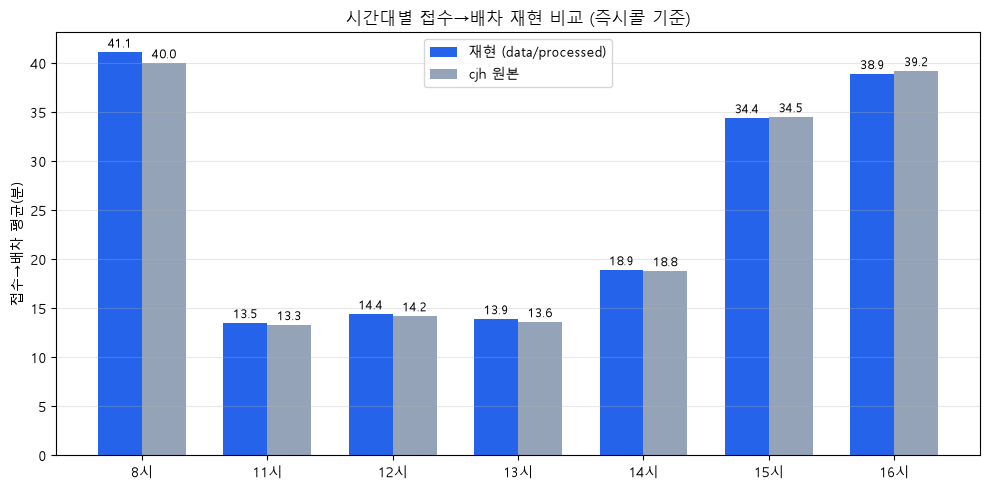

In [5]:
import matplotlib.pyplot as plt

if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(compare_df))
width = 0.35

bars_mine = ax.bar(
    [i - width / 2 for i in x], compare_df['재현_접수배차'], width,
    label='재현 (data/processed)', color='#2563eb'
)
bars_cjh = ax.bar(
    [i + width / 2 for i in x], compare_df['cjh_접수배차'], width,
    label='cjh 원본', color='#94a3b8'
)

ax.set_xticks(list(x))
ax.set_xticklabels(compare_df['시간대'])
ax.set_ylabel('접수→배차 평균(분)')
ax.set_title('시간대별 접수→배차 재현 비교 (즉시콜 기준)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bars in (bars_mine, bars_cjh):
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width() / 2, h + 0.5, f'{h:.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 2) 14→15→16시 접수/탑승 흐름 (SVG 14의 카드 3개 검증)

접수 건수는 `접수시간대` 기준, 탑승 건수는 `승차일시`의 실제 발생 시각 기준으로 집계해야
"그 시간대에 몰린 요청이 이후 시간대 탑승으로 밀린다"는 흐름이 맞게 나온다.

In [6]:
df['승차시간대'] = df['승차일시'].dt.hour

req_by_hour = df.groupby('접수시간대').size()
board_by_hour = df.groupby('승차시간대').size()

flow_rows = []
for h in [14, 15, 16]:
    req = int(req_by_hour.get(h, 0))
    board = int(board_by_hour.get(h, 0))
    flow_rows.append({'시간대': f'{h}시', '접수': req, '탑승(그시각발생)': board, '차이': req - board})

flow_df = pd.DataFrame(flow_rows)
flow_df

,시간대,접수,탑승(그시각발생),차이
0,14시,197592,148070,49522
1,15시,176026,129623,46403
2,16시,97434,105566,-8132


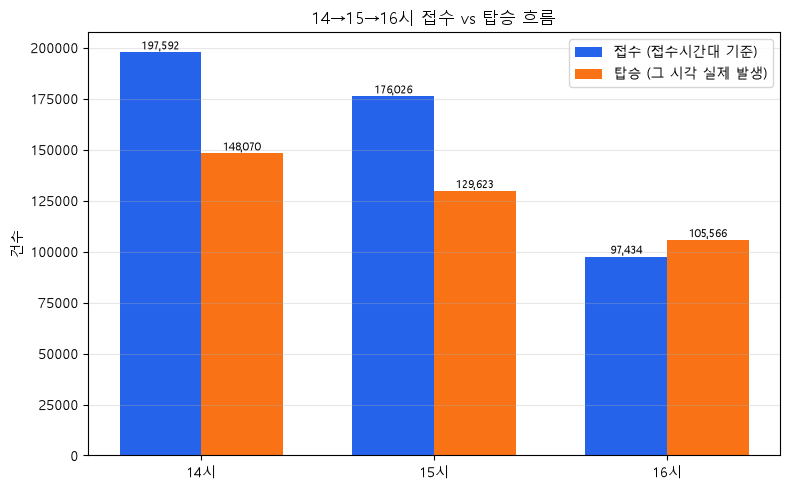

In [7]:
if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(flow_df))
width = 0.35

bars_req = ax.bar(
    [i - width / 2 for i in x], flow_df['접수'], width,
    label='접수 (접수시간대 기준)', color='#2563eb'
)
bars_board = ax.bar(
    [i + width / 2 for i in x], flow_df['탑승(그시각발생)'], width,
    label='탑승 (그 시각 실제 발생)', color='#f97316'
)

ax.set_xticks(list(x))
ax.set_xticklabels(flow_df['시간대'])
ax.set_ylabel('건수')
ax.set_title('14→15→16시 접수 vs 탑승 흐름')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bars in (bars_req, bars_board):
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width() / 2, h + 1500, f'{h:,.0f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

## 3) 15시 출발구별 접수→배차 병목 TOP 8 (SVG 13 지역 표 검증)

즉시콜 기준, 15시에 접수된 건만 필터링 후 출발구별 집계.
서울 25개 자치구 외(경기/인천 등 극소수 표본) 지역은 평균을 왜곡시키므로 제외한다.

In [8]:
seoul_25_gu = [
    '종로구', '중구', '용산구', '성동구', '광진구',
    '동대문구', '중랑구', '성북구', '강북구', '도봉구',
    '노원구', '은평구', '서대문구', '마포구', '양천구',
    '강서구', '구로구', '금천구', '영등포구', '동작구',
    '관악구', '서초구', '강남구', '송파구', '강동구',
]

h15 = df_immediate[
    (df_immediate['접수시간대'] == 15)
    & (df_immediate['출발구'].isin(seoul_25_gu))
].copy()
h15['탑승여부'] = h15['승차일시'].notna()
h15['취소여부'] = h15['취소일시'].notna()
h15['전체대기_분'] = h15['접수_배차_분'].fillna(0) + h15['배차_승차_분'].fillna(0)

region_15 = (
    h15.groupby('출발구')
    .agg(
        접수건수=('접수일시', 'size'),
        접수배차_평균=('접수_배차_분', 'mean'),
        전체대기_평균=('전체대기_분', 'mean'),
        취소건수=('취소여부', 'sum'),
    )
    .round(1)
)
region_15['취소율(%)'] = (region_15['취소건수'] / region_15['접수건수'] * 100).round(1)
region_15 = region_15.sort_values('접수배차_평균', ascending=False)

# 주의: 원본 SVG 파일의 한글 텍스트 인코딩이 깨져 있어 구 이름은 신뢰할 수 없고,
# 숫자(분/%/건수)만 원본 그대로 읽을 수 있었다. 이름 대신 값만 비교한다.
print('cjh 원본 TOP4 접수→배차(분): 62.1, 56.8, 56.7, 56.0  (구 이름은 SVG 인코딩 손상으로 확인 불가)')
region_15.head(8)

cjh 원본 TOP4 접수→배차(분): 62.1, 56.8, 56.7, 56.0  (구 이름은 SVG 인코딩 손상으로 확인 불가)


,접수건수,접수배차_평균,전체대기_평균,취소건수,취소율(%)
출발구,,,,,
서대문구,10348,60.8,66.7,2334,22.6
종로구,6326,56.1,59.2,1875,29.6
중구,3076,56.0,62.8,820,26.7
서초구,5780,55.5,58.1,1865,32.3
용산구,2578,53.4,58.1,747,29.0
마포구,9174,46.5,53.3,2006,21.9
영등포구,9615,46.4,57.0,1879,19.5
동작구,4737,43.0,48.1,1259,26.6


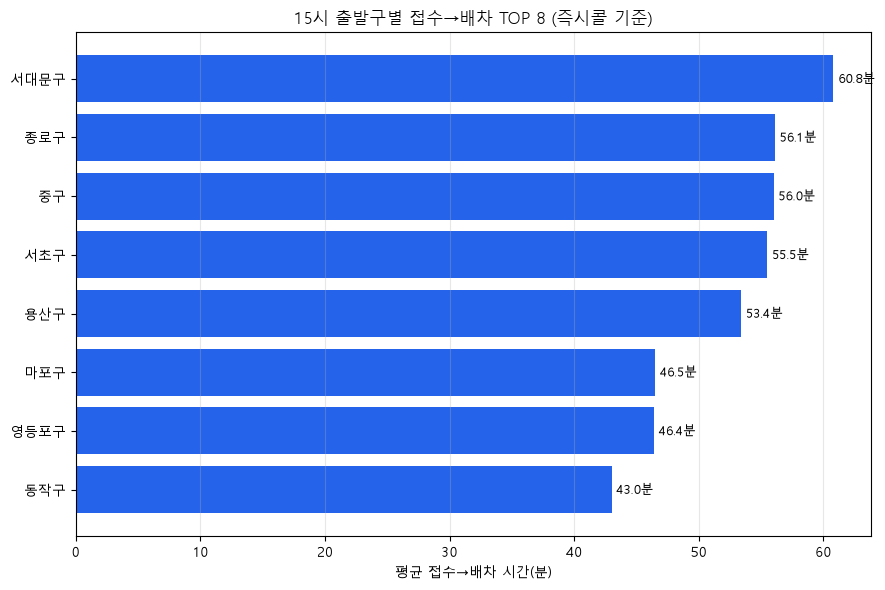

In [9]:
if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

plot_data = region_15.head(8).sort_values('접수배차_평균')

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(plot_data.index, plot_data['접수배차_평균'], color='#2563eb')
ax.set_xlabel('평균 접수→배차 시간(분)')
ax.set_title('15시 출발구별 접수→배차 TOP 8 (즉시콜 기준)')
ax.grid(axis='x', alpha=0.3)

for i, v in enumerate(plot_data['접수배차_평균']):
    ax.text(v, i, f' {v:.1f}분', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 4) 15시 출발구별 배차→승차 병목 TOP 8 (SVG 14 지역 표 검증)

In [10]:
region_15_board = (
    h15.groupby('출발구')
    .agg(
        접수건수=('접수일시', 'size'),
        배차승차_평균=('배차_승차_분', 'mean'),
        접수배차_평균=('접수_배차_분', 'mean'),
        전체대기_평균=('전체대기_분', 'mean'),
    )
    .round(1)
    .sort_values('배차승차_평균', ascending=False)
)

print('cjh 원본 TOP4 배차→승차(분): 25.0, 24.0, 23.4, 22.9  (구 이름은 SVG 인코딩 손상으로 확인 불가)')
region_15_board.head(8)

cjh 원본 TOP4 배차→승차(분): 25.0, 24.0, 23.4, 22.9  (구 이름은 SVG 인코딩 손상으로 확인 불가)


,접수건수,배차승차_평균,접수배차_평균,전체대기_평균
출발구,,,,
중구,3076,24.9,56.0,62.8
용산구,2578,24.0,53.4,58.1
서초구,5780,23.4,55.5,58.1
종로구,6326,22.8,56.1,59.2
영등포구,9615,21.5,46.4,57.0
강남구,5764,20.9,40.2,47.8
서대문구,10348,20.8,60.8,66.7
성북구,6286,20.6,32.1,45.0


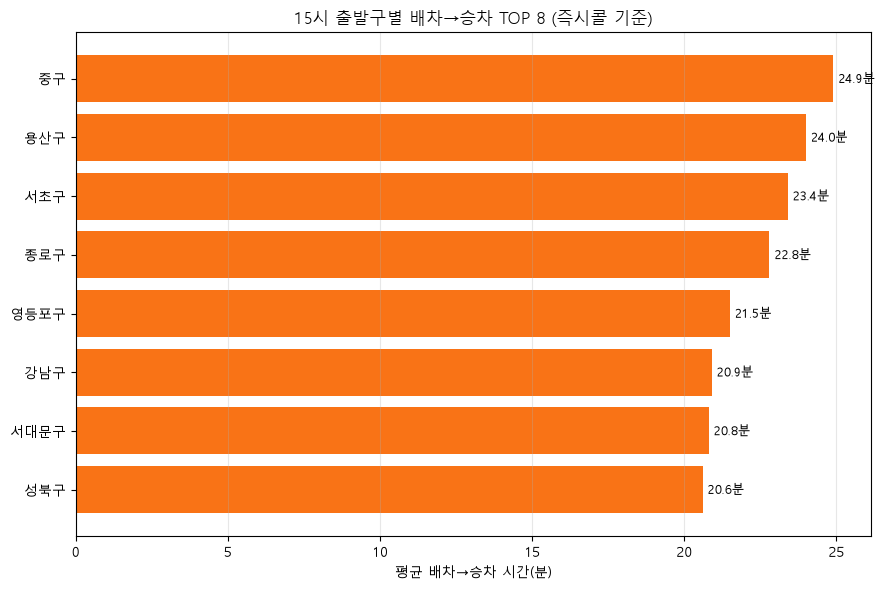

In [11]:
if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

plot_data = region_15_board.head(8).sort_values('배차승차_평균')

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(plot_data.index, plot_data['배차승차_평균'], color='#f97316')
ax.set_xlabel('평균 배차→승차 시간(분)')
ax.set_title('15시 출발구별 배차→승차 TOP 8 (즉시콜 기준)')
ax.grid(axis='x', alpha=0.3)

for i, v in enumerate(plot_data['배차승차_평균']):
    ax.text(v, i, f' {v:.1f}분', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 결론

- **패턴은 정제된 데이터에서도 그대로 재현된다**: 14→15→16시 구간에서 접수→배차 시간이 급증하고,
  배차→승차 시간은 상대적으로 완만하게 늘어난다. cjh의 "배차 전 단계가 병목"이라는 결론이 유지된다.
- **절대 수치는 즉시콜(비예약)만 걸러야 cjh 원본과 일치한다.** 예약 유형을 포함하면 접수→배차 평균이
  7배 이상(예: 8시 40분 → 285분) 부풀려진다. 이 필터링 기준이 cjh 노트북/스크립트에 있었을 가능성이 높다.
- 남는 소수점 단위 오차(0.1~0.5분 수준)는 01번 정제에서 아직 확정 안 된 판단 3건
  (완전중복 130건, 위치정보 결측 1건, 4/20 무료운행 관련 81건) 때문일 가능성이 있다 — 그 판단이 끝나면
  오차가 더 줄어들 것으로 예상된다.
- SVG 15(배차방식/픽업거리 불균형)의 "픽업거리 40점"은 실제 좌표 기반이 아니라 근사치라고 원본에도
  명시돼 있어, 정확한 산식 없이는 그대로 재현하기 어렵다. `data/raw/서울시설공단_장애인콜택시 차고지 정보`를
  공급측 근사치로 활용할 수 있을 것으로 보이며, cjh에게 원래 산식을 확인하는 게 우선이다.